<a href="https://colab.research.google.com/github/ironspiritjeff/Ames-Iowa-House-Price-Regression-Model/blob/main/House_Price_Regression_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏡 End-to-End House Price Predictor - Regression Model

**Dataset:** House Prices - Advanced Regression Techniques
  * https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview

**Objective:** Predict the continuous target variable (Price) using Scikit-Learn, Pandas, and NumPy.  
**Methodology:** Use Just-In-Time (JIT) Documentation Retrieval & Deep Problem Solving to solve each section before writing code. Do not use video tutorials.

**Reference Notebook Tooling:** Use only to verify architectural direction, never to copy syntax.

---

## 🧭 The JIT Retention Rules
1. **The 5-Minute Sandbox:** When stuck or hitting an error, spend 5 minutes reading the official documentation or the Python error trace before looking at the Kaggle reference notebook.
2. **The "Why" Test:** Before running any code cell, ask yourself: *What exactly am I expecting this line to return, and why am I using this specific library over another?*
3. **No Copy-Pasting:** Every line of code must be manually typed out by your own fingers to build syntax familiarity.

---

## 🏃‍♂️ Phase 1: Data Isolation & Leakage Prevention
*Goal: Secure your evaluation data before your brain or your code can look at it.*

### ❓ Core Question: How do I split data safely to avoid Data Leakage?
*   **The Theory:** Data leakage happens when training features accidentally look at the validation data (like calculating the mean of the *entire* dataset before splitting). This makes your model look smart during testing but fail completely in production.
*   *JIT Reading Anchor:* Read the Scikit-Learn user guide on "Data Leakage" to understand why we split data *before* preprocessing.

### 🛠️ Execution Checklist
- [ ] **Step 1.1:** Load the `train.csv` file using Pandas. Inspect the dimensions using `.shape`.
- [ ] **Step 1.2:** Separate the target variable (`SalePrice`) into a vector `y` and the independent features into a DataFrame `X`.
- [ ] **Step 1.3:** Use `sklearn.model_selection.train_test_split` to create `X_train`, `X_val`, `y_train`, and `y_val` (use an 80/20 split).
- [ ] **Step 1.4:** Verify that your future preprocessors are only ever `.fit()` on `X_train` and merely `.transform()` on `X_val`.

---


## 📊 Phase 2: Target Variable Analysis & Normalization
*Goal: Analyze and stabilize the mathematical distribution of your predictions.*

### ❓ Core Question: How do I check if my target variable is "Skewed"?
*   **The Theory:** If your housing prices are heavily skewed (e.g., a few massive $3,000,000 mansions dragging out a long right tail), standard regression algorithms struggle to capture the pattern accurately. Transforming the target distribution into a normal bell curve allows algorithms to converge efficiently.
*   *JIT Reading Anchor:* Read the NumPy documentation for `log1p` and `expm1` to understand how to reverse this calculation later.

### 🛠️ Execution Checklist
- [ ] **Step 2.1:** Use Matplotlib or Seaborn to plot a raw histogram of `y_train`.
- [ ] **Step 2.2:** Calculate the skewness statistic using the Pandas feature `.skew()`.
- [ ] **Step 2.3:** If the skewness score is greater than 1.0, apply a logarithmic transformation to both `y_train` and `y_val` using `numpy.log1p()`.
- [ ] **Step 2.4:** Re-plot the histogram of your log-transformed target to verify it resembles a standard bell curve.

---

## 🧹 Phase 3: Feature Discrimination & Advanced Preprocessing
*Goal: Deal with the 79 columns by breaking them down into logical, machine-readable types.*

### ❓ Core Question A: How do I handle missing data without dropping rows?
*   **The Theory:** Real datasets have gaps. Indiscriminately dropping rows removes valuable training samples. Replacing missing values mathematically requires an intentional strategy: numeric features can be filled with middle values (like the median) to mitigate the influence of outliers, while categorical gaps require a placeholder label or the most frequent class.
*   **JIT Reading Anchor:** Look up the parameters for `sklearn.impute.SimpleImputer`.

### ❓ Core Question B: How do I turn text categories into numbers properly?
*   **The Theory:** Algorithms only process math, not strings. Unordered columns (Nominal text like `Neighborhood`) must be spread across binary columns using One-Hot Encoding so the model doesn't assume neighborhood "B" is mathematically greater than neighborhood "A". Ordered columns (Ordinal text like `ExterQual`: Poor, Fair, Typical, Good, Excellent) must be mapped to ranked integers.
*   **JIT Reading Anchor:** Review `sklearn.preprocessing.OneHotEncoder` and `sklearn.preprocessing.OrdinalEncoder`.

### 🛠️ Execution Checklist
- [ ] **Step 3.1:** Identify your missing data profile using `X_train.isna().sum()`. Note which columns are missing values.
- [ ] **Step 3.2:** Programmatically split your columns into a `numeric_features` list and a `categorical_features` list.
*   [ ] **Step 3.3:** Use `sklearn.impute.SimpleImputer` to fill missing numeric data with the median.
*   [ ] **Step 3.4:** Identify which categorical columns are **Ordinal** (e.g., `ExterQual`: Ex, Gd, TA, Fa) vs. **Nominal** (e.g., `Neighborhood`).
- [ ] **Step 3.4.1:** Map your ordinal columns to matching ordered integers manually or via `OrdinalEncoder`.
- [ ] **Step 3.5:** Apply `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to your remaining nominal text columns to prevent dimension mismatches when checking validation data.

*   *JIT Reading Anchor:* Look up the documentation parameters for `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to prevent dimension errors during validation.
---

## 🤖 Phase 4: Baseline Training & Evaluation Framework
*Goal: Build a solid evaluation metric to track your model's true performance.*

### ❓ Core Question: How do I evaluate a regression model?
*   **The Theory:** Classification metrics like accuracy scores do not work when predicting continuous prices. If a house costs $300,000 and your model guesses $295,000, it is technically "wrong," but practically excellent. You must measure real dollar errors using Mean Absolute Error (MAE) for average distance, and Root Mean Squared Error (RMSE) to penalize rare, massive misses.
*   **JIT Reading Anchor:** Read the Scikit-Learn metrics user guide covering `mean_absolute_error` and `root_mean_squared_error`.

### 🛠️ Execution Checklist
- [ ] **Step 4.1:** Write a reusable Python function named `evaluate_regression(y_true, y_pred)` that explicitly prints out calculated MAE, RMSE, and $R^2$ scores.
- [ ] **Step 4.2:** Instantiate a baseline `sklearn.ensemble.RandomForestRegressor`.
- [ ] **Step 4.3:** Fit the regressor on your processed training arrays and output predictions from your validation feature set (`X_val`).
- [ ] **Step 4.4:** Convert your validation predictions back to real dollar limits using `numpy.expm1()` before running them through your evaluation function.

*   *JIT Reading Anchor:* Read the Scikit-Learn documentation metrics module specifically comparing MAE (average dollar error) to RMSE (penalty for large misses).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
from sklearn.model_selection import train_test_split
import random

Import and view data:

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Ames Housing Dataset/train.csv')
print(f"Shape of dataframe: {df.shape}")

Shape of dataframe: (1460, 81)


In [4]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Separate the target column ("SalePrice") from the rest of the data

In [5]:
X = df.drop(["SalePrice"], axis = 1)
y = df["SalePrice"]
print(f"First 5 items in target column, now called 'y':\n{y.head()}")

First 5 items in target column, now called 'y':
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


Split the whole dataset before making changes to it.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=7)

In [7]:
print(f"X_train shape: {X_train.shape}    (These feature columns will be used for training)")
print(f"X_val shape: {X_val.shape}       (These feature columns will be used for validation)")
print(f"y_train shape: {y_train.shape}       (These target columns will be used for training)")
print(f"y_val shape: {y_val.shape}          (These target columns will be used for validation)")

X_train shape: (1168, 80)    (These feature columns will be used for training)
X_val shape: (292, 80)       (These feature columns will be used for validation)
y_train shape: (1168,)       (These target columns will be used for training)
y_val shape: (292,)          (These target columns will be used for validation)


## 📊 Phase 2: Target Variable Analysis & Normalization
*Goal: Analyze and stabilize the mathematical distribution of your predictions.*

### 🛠️ Execution Checklist
- [ ] **Step 2.1:** Use Matplotlib or Seaborn to plot a raw histogram of `y_train`.
- [ ] **Step 2.2:** Calculate the skewness statistic using the Pandas feature `.skew()`.
- [ ] **Step 2.3:** If the skewness score is greater than 1.0, apply a logarithmic transformation to both `y_train` and `y_val` using `numpy.log1p()`.
- [ ] **Step 2.4:** Re-plot the histogram of your log-transformed target to verify it resembles a standard bell curve.

---

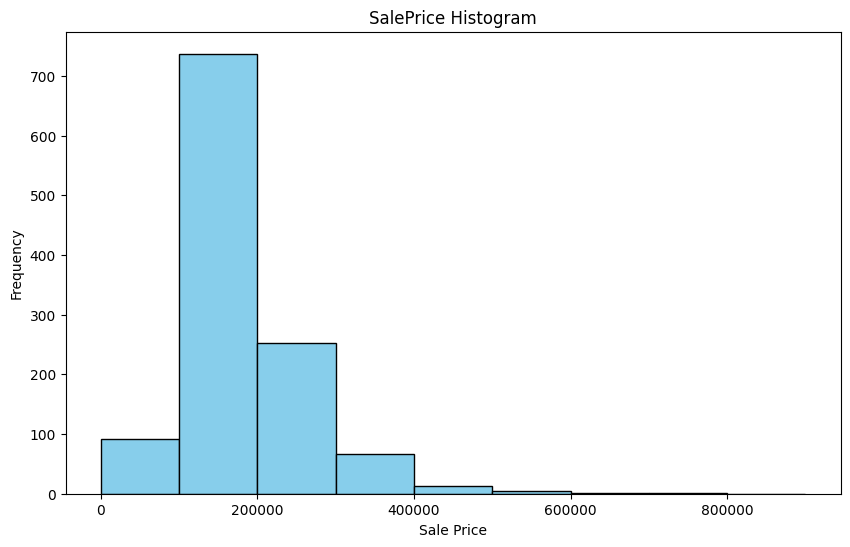

Bin counts: [ 91. 737. 252.  67.  13.   5.   2.   1.   0.]
Bin edges: [     0. 100000. 200000. 300000. 400000. 500000. 600000. 700000. 800000.
 900000.]


In [8]:
custom_bins = [0,100000,200000,300000,400000,500000,600000,700000,800000,900000]

plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(y_train,
                           bins=custom_bins,
                           color='skyblue', edgecolor='black')

plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title("SalePrice Histogram")
plt.show()

print("Bin counts:", counts)
print("Bin edges:", bins)

In [9]:
skew = y_train.skew()
skew

np.float64(1.8486514711896795)

###Problem: Data is skewed (ie, the histogram above has a "tail" because of a few very expensive houses)
The SalePrice Histogram (and the skew value of ~1.85) show that the data is highly skewed, meaning that a few extreme outliers will cause the model to learn the wrong pattern.

###Solution: Apply `log1p` transformation to reduce the effect of these extreme outliers.
To fix this, a logarithmic transformation will compress the value of the outliers. Specifically, `log1p` will be applied, which reduces the impact of large values, bringing the data closer to a symetrical normal-like distribution, which is optimal for many machine learning algorithms.

**Note:** This will be reversed later so that once the model has made predictions, those predictions are brought back to their original scale.

In [10]:
# log1p will be applied to the all target values, in both the training and validation splits.
log_y_train = np.log1p(y_train)
log_y_val = np.log1p(y_val)

In [11]:
print(log_y_train.skew())
print(log_y_val.skew())

0.0696233222933637
0.3034206873327211


The new skew values are much closer to zero, which is what we want. (Between 0-0.5 is  normally recommended.) Let's visualize this with a new histogram which shows the log transformed Sale Prices, for both training and validation.

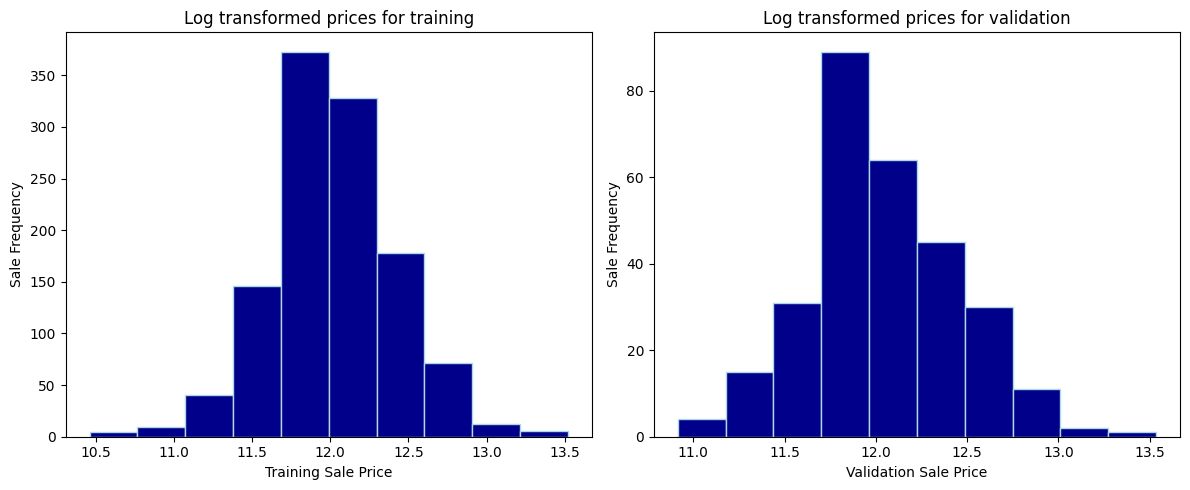

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(log_y_train, bins=10, color='darkblue', edgecolor='lightblue')
plt.xlabel("Training Sale Price")
plt.ylabel("Sale Frequency")
plt.title("Log transformed prices for training")

plt.subplot(1,2,2)
plt.hist(log_y_val, bins=10, color='darkblue', edgecolor='lightblue')
plt.xlabel("Validation Sale Price")
plt.ylabel("Sale Frequency")
plt.title("Log transformed prices for validation")

plt.tight_layout()
plt.show()

The Sale Prices are now compressed in to more of a bell shaped curve, representing all of the data, but with no extreme outliers.

---

## 🧹 Phase 3: Feature Discrimination & Advanced Preprocessing
*Goal: Deal with the 79 columns by breaking them down into logical, machine-readable types.*

### ❓ Core Question A: How do I handle missing data without dropping rows?
*   **The Theory:** Real datasets have gaps. Indiscriminately dropping rows removes valuable training samples. Replacing missing values mathematically requires an intentional strategy: numeric features can be filled with middle values (like the median) to mitigate the influence of outliers, while categorical gaps require a placeholder label or the most frequent class.
*   **JIT Reading Anchor:** Look up the parameters for `sklearn.impute.SimpleImputer`.

### ❓ Core Question B: How do I turn text categories into numbers properly?
*   **The Theory:** Algorithms only process math, not strings. Unordered columns (Nominal text like `Neighborhood`) must be spread across binary columns using One-Hot Encoding so the model doesn't assume neighborhood "B" is mathematically greater than neighborhood "A". Ordered columns (Ordinal text like `ExterQual`: Poor, Fair, Typical, Good, Excellent) must be mapped to ranked integers.
*   **JIT Reading Anchor:** Review `sklearn.preprocessing.OneHotEncoder` and `sklearn.preprocessing.OrdinalEncoder`.

### 🛠️ Execution Checklist
- [ ] **Step 3.1:** Identify your missing data profile using `X_train.isna().sum()`. Note which columns are missing values.
- [ ] **Step 3.2:** Programmatically split your columns into a `numeric_features` list and a `categorical_features` list.
*   [ ] **Step 3.3:** Use `sklearn.impute.SimpleImputer` to fill missing numeric data with the median.
*   [ ] **Step 3.4:** Identify which categorical columns are **Ordinal** (e.g., `ExterQual`: Ex, Gd, TA, Fa) vs. **Nominal** (e.g., `Neighborhood`).
- [ ] **Step 3.4.1:** Map your ordinal columns to matching ordered integers manually or via `OrdinalEncoder`.
- [ ] **Step 3.5:** Apply `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to your remaining nominal text columns to prevent dimension mismatches when checking validation data.

*   *JIT Reading Anchor:* Look up the documentation parameters for `OneHotEncoder(handle_unknown='ignore', sparse_output=False)` to prevent dimension errors during validation.
---

Now we get into the nitty gritty. Machine learning models can only understand numbers, and they don't know what to do with missing values or with words we use in English (called "strings"). The problem is, the Ames Housing Prices dataset like most real-world datasets is missing values and it also has non-numeric values too - as in the column names like "GarageArea".



Let's start by visualizing how incomplete the dataset is. We'll do this by counting how many missing values are in each column.


In [18]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print(X_train.isna().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       206
LotArea             0
Street              0
Alley            1095
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        687
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           32
BsmtCond           32
BsmtExposure       32
BsmtFinType1       32
BsmtFinSF1          0
BsmtFinType2       33
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          0
1stFlrSF            0
2ndFlrSF            0
LowQualFin

Just by looking at the missing values shown above, we can see that around 1/3 of all columns contain some (or many!) missing values. This means that when the model is trained on this dataset, it will either crash, or it will substitute a value of `0` in these columns, when in reality the number is unknown. Unless this is fixed, the model will not perform at all, or it will learn from false patterns.

In [ ]:
df.select_dtypes(include=int)

### Step 3.2: Programmatically split columns into numeric and categorical lists

We'll use pandas `select_dtypes` to automatically identify columns that are numeric and those that are considered categorical (object type in pandas).

In [ ]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numeric features ({len(numeric_features)}):\n{numeric_features}\n")
print(f"Categorical features ({len(categorical_features)}):\n{categorical_features}")